# Histogram of IoU per image (Test Set)

Loads a trained model, runs inference on Fire images from the test set,
computes per-image mean IoU (predicted bboxes vs GT), generates a histogram,
and copies images into bad/medium/good folders.

In [1]:
import os
import sys
import shutil

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

from core.config.config import get_config, get_active_dataset_config, log_info, set_root_path
from core.models import get_model, load_model, add_attn_maps
from core.datasets import get_data_loaders
from core.metrics import load_coco_bboxes_from_json, normalize_bbox, compute_iou
from core.attention_map import get_last_layer_attention
from core.vis_utils import VisUtils, compute_dynamic_threshold
from core.debug import remove_nested_bboxes

%matplotlib inline
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/haranaka/Development/FireClassification


/Users/haranaka/Development/FireClassification/core/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/haranaka/Development/FireClassification/core/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/haranaka/Development/FireClassification/core/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/Users/haranaka/Development/FireClassification/.venv/lib/python3.13/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## Parameters

In [15]:
MODEL_NAME = "DinoV2RS_Small"
CHECKPOINT_PATH = None
CHECKPOINT_PATH = "models/DinoV2RS_Small_seed_42.pth"
ROOT_PATH = None
BATCH_SIZE = 1
NUM_WORKERS = 0
DEVICE = None
OUTPUT_DIR = "histogram_results"

## Setup: device, model, data

In [3]:
def get_device_auto():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

if DEVICE:
    device = torch.device(DEVICE)
else:
    device = get_device_auto()
print(f"Using device: {device}")

if ROOT_PATH:
    set_root_path(ROOT_PATH)

root_path = get_active_dataset_config("data_path") or "data"
num_classes = get_active_dataset_config("num_classes") or 2

img_size = get_config("models", MODEL_NAME, "img_size")
img_size = int(img_size) if img_size is not None else 256
print(f"Image size: {img_size}")

Using device: mps
Image size: 672


In [16]:
print(f"Loading model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_classes=num_classes, device=device)
if CHECKPOINT_PATH:
    state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Model loaded from: {CHECKPOINT_PATH}")
else:
    load_model(model, MODEL_NAME)
if "Dino" not in MODEL_NAME:
    model = add_attn_maps(model)
print("Model loaded.")

[2026-02-19 16:31:24] INFO:     using MLP layer as FFN


Loading model: DinoV2RS_Small
Model loaded from: models/DinoV2RS_Small_seed_42.pth
Model loaded.


In [5]:
data_loaders, _ = get_data_loaders(
    root_path=root_path,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    img_size=img_size,
)
test_loader = data_loaders["Test"]

test_path = os.path.join(root_path, "Test")
gt_bboxes_by_filename = load_coco_bboxes_from_json(test_path, target_size=img_size)
print(f"Loaded GT bboxes for {len(gt_bboxes_by_filename)} images")

[2026-02-19 16:28:28] INFO:     Loading dataloaders...
[2026-02-19 16:28:28] INFO:     COCO Fire dataset loaded: 1096 images
[2026-02-19 16:28:28] INFO:       Fire: 531
[2026-02-19 16:28:28] INFO:       Not: 565
[2026-02-19 16:28:28] INFO:     COCO Fire dataset loaded: 469 images
[2026-02-19 16:28:28] INFO:       Fire: 228
[2026-02-19 16:28:28] INFO:       Not: 241
[2026-02-19 16:28:28] INFO:     Image size: 672


Loaded GT bboxes for 531 images


## Compute per-image IoU

In [6]:
def compute_image_mean_iou(gt_bboxes_coco, pred_bboxes):
    if not gt_bboxes_coco:
        return 0.0

    best_ious = []
    for gt in gt_bboxes_coco:
        gt_x1, gt_y1, gt_x2, gt_y2 = normalize_bbox(gt[:4])

        best_iou = 0.0
        for pred in pred_bboxes:
            pred_box = [float(pred[0]), float(pred[1]), float(pred[2]), float(pred[3])]
            iou = compute_iou([gt_x1, gt_y1, gt_x2, gt_y2], pred_box)
            best_iou = max(best_iou, iou)
        best_ious.append(best_iou)

    return float(np.mean(best_ious)) if best_ious else 0.0

In [17]:
min_bbox_area = get_config("defaults", "min_bbox_area") or 1600

image_ious = []
total_processed = 0

print("Processing test set images...")
with torch.no_grad():
    for batch_idx, batch_data in enumerate(test_loader):
        if len(batch_data) >= 3:
            images, labels, paths = batch_data[0], batch_data[1], batch_data[2]
        else:
            continue

        images = images.to(device)
        batch_size_actual = images.size(0)

        for i in range(batch_size_actual):
            label = labels[i].item() if isinstance(labels, torch.Tensor) else int(labels[i])

            if label != 0:
                continue

            img_path = paths[i]
            filename = os.path.basename(img_path)

            if filename not in gt_bboxes_by_filename:
                continue

            gt_bboxes = gt_bboxes_by_filename[filename]

            img_tensor = images[i:i + 1]
            try:
                attn_np = get_last_layer_attention(model, MODEL_NAME, img_tensor)
            except Exception as e:
                print(f"Attention extraction failed for {filename}: {e}")
                continue

            threshold = compute_dynamic_threshold(attn_np, method="otsu", fire_adapted=True)
            bbs_raw = VisUtils.generate_bounding_box(attn_np, threshold=threshold, min_area=min_bbox_area)

            if len(bbs_raw) > 1:
                bbs_raw = remove_nested_bboxes(bbs_raw, containment_threshold=0.5)

            if not bbs_raw:
                image_ious.append((filename, 0.0, img_path, gt_bboxes, []))
                total_processed += 1
                continue

            mean_iou = compute_image_mean_iou(gt_bboxes, bbs_raw)
            image_ious.append((filename, mean_iou, img_path, gt_bboxes, bbs_raw))
            total_processed += 1

        if (batch_idx + 1) % max(1, len(test_loader) // 10) == 0:
            print(f"  Processed {total_processed} Fire images so far...")

print(f"Total Fire images processed: {total_processed}")

Processing test set images...
  Processed 53 Fire images so far...
  Processed 100 Fire images so far...
  Processed 154 Fire images so far...
  Processed 207 Fire images so far...
  Processed 262 Fire images so far...
  Processed 311 Fire images so far...
  Processed 373 Fire images so far...
  Processed 433 Fire images so far...
  Processed 485 Fire images so far...
  Processed 530 Fire images so far...
Total Fire images processed: 531


In [8]:
if "image_ious_ref" not in dir():
    image_ious_ref = list(image_ious)
    print(f"Reference set saved: {len(image_ious_ref)} images, {sum(1 for _, iou, *_ in image_ious_ref if iou < 0.3)} bad")
else:
    print(f"Reference set already saved ({len(image_ious_ref)} images) — not overwritten")

Reference set saved: 531 images, 104 bad


## Generate Histogram

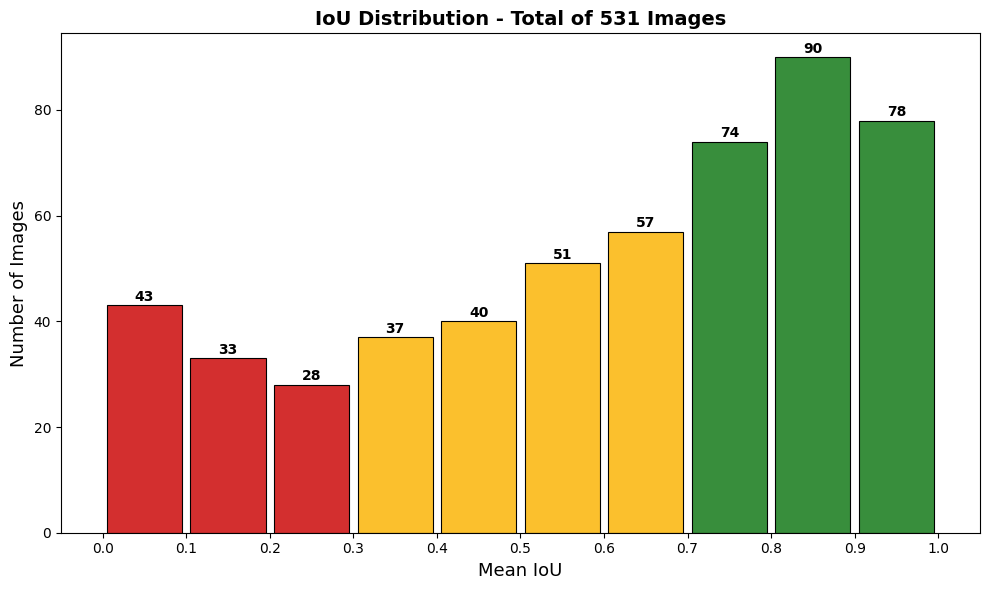

Histogram saved to: histogram_results/histogram_iou_DinoV2RS_Small.png


In [9]:
ious = np.array([x[1] for x in image_ious])

os.makedirs(OUTPUT_DIR, exist_ok=True)

bin_edges = np.arange(0, 1.1, 0.1)
counts, _ = np.histogram(ious, bins=bin_edges)

colors = []
for j in range(len(counts)):
    center = (bin_edges[j] + bin_edges[j + 1]) / 2
    if center < 0.3:
        colors.append("#d32f2f")
    elif center < 0.7:
        colors.append("#fbc02d")
    else:
        colors.append("#388e3c")

fig, ax = plt.subplots(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.bar(bin_centers, counts, width=0.09, color=colors, edgecolor="black", linewidth=0.8)

ax.set_xlabel("Mean IoU", fontsize=13)
ax.set_ylabel("Number of Images", fontsize=13)
ax.set_title(f"IoU Distribution - Total of {len(ious)} Images", fontsize=14, weight="bold")
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_xlim(-0.05, 1.05)

for j, (c, cnt) in enumerate(zip(bin_centers, counts)):
    if cnt > 0:
        ax.text(c, cnt + 0.3, str(cnt), ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()

hist_path = os.path.join(OUTPUT_DIR, f"histogram_iou_{MODEL_NAME}.png")
plt.savefig(hist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Histogram saved to: {hist_path}")

## Copy images into bad/medium/good folders

In [10]:
for folder in ["bad", "medium", "good"]:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

bad_count, med_count, good_count = 0, 0, 0
for filename, iou_val, img_path, gt_bboxes, pred_bboxes in image_ious:
    if iou_val < 0.3:
        dest = os.path.join(OUTPUT_DIR, "bad", filename)
        bad_count += 1
    elif iou_val < 0.7:
        dest = os.path.join(OUTPUT_DIR, "medium", filename)
        med_count += 1
    else:
        dest = os.path.join(OUTPUT_DIR, "good", filename)
        good_count += 1

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", size=20)
    except (OSError, IOError):
        font = ImageFont.load_default()

    for gt in gt_bboxes:
        x1, y1, x2, y2 = normalize_bbox(gt[:4])
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
        draw.text((x1, max(0, y1 - 22)), "GT", fill="lime", font=font)

    for pred in pred_bboxes:
        px1, py1, px2, py2 = float(pred[0]), float(pred[1]), float(pred[2]), float(pred[3])
        draw.rectangle([px1, py1, px2, py2], outline="red", width=3)
        draw.text((px1, max(0, py1 - 22)), "Pred", fill="red", font=font)

    iou_text = f"IoU: {iou_val:.3f}"
    bbox = draw.textbbox((0, 0), iou_text, font=font)
    text_w, text_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.rectangle([5, 5, 5 + text_w + 10, 5 + text_h + 10], fill="black")
    draw.text((10, 8), iou_text, fill="white", font=font)

    img.save(dest)

print(f"Saved {bad_count + med_count + good_count} annotated images.")

Saved 531 annotated images.


## Summary

In [11]:
print(f"{'=' * 60}")
print(f"IoU HISTOGRAM SUMMARY - {MODEL_NAME}")
print(f"{'=' * 60}")
print(f"Total Fire images: {len(ious)}")
print(f"Mean IoU:   {ious.mean():.4f}")
print(f"Median IoU: {np.median(ious):.4f}")
print(f"Std IoU:    {ious.std():.4f}")
print(f"Min IoU:    {ious.min():.4f}")
print(f"Max IoU:    {ious.max():.4f}")
print(f"{'-' * 60}")
print(f"Bad   (IoU < 0.3):  {bad_count} images")
print(f"Medium (0.3-0.7):   {med_count} images")
print(f"Good  (IoU >= 0.7): {good_count} images")
print(f"{'-' * 60}")
print(f"Histogram: {hist_path}")
print(f"Images copied to: {OUTPUT_DIR}/bad/, medium/, good/")
print(f"{'=' * 60}")

IoU HISTOGRAM SUMMARY - DinoV2RS_Small
Total Fire images: 531
Mean IoU:   0.5932
Median IoU: 0.6535
Std IoU:    0.2851
Min IoU:    0.0000
Max IoU:    0.9849
------------------------------------------------------------
Bad   (IoU < 0.3):  104 images
Medium (0.3-0.7):   185 images
Good  (IoU >= 0.7): 242 images
------------------------------------------------------------
Histogram: histogram_results/histogram_iou_DinoV2RS_Small.png
Images copied to: histogram_results/bad/, medium/, good/


## Analysis of Bad Cases - Dataset vs Model

In [12]:
bad_images = [(fn, iou, path, gts, preds) for fn, iou, path, gts, preds in image_ious if iou < 0.3]

categories = {
    "Dark image": [],
    "Dominant green background": [],
    "Small fire (GT < 5% of image)": [],
    "Multiple fire sources (>= 3 GTs)": [],
    "No prediction": [],
    "Other": [],
}

img_area = img_size * img_size

for fn, iou, path, gts, preds in bad_images:
    if not os.path.exists(path):
        continue

    img = Image.open(path).convert("RGB").resize((img_size, img_size))
    pixels = np.array(img, dtype=np.float32)

    assigned = False

    if len(preds) == 0:
        categories["No prediction"].append(fn)
        assigned = True

    brightness = pixels.mean()
    if brightness < 50:
        categories["Dark image"].append(fn)
        assigned = True

    mean_r, mean_g, mean_b = pixels[:,:,0].mean(), pixels[:,:,1].mean(), pixels[:,:,2].mean()
    if mean_g > mean_r and mean_g > mean_b and mean_g > 80:
        categories["Dominant green background"].append(fn)
        assigned = True

    max_gt_area = 0
    for gt in gts:
        x1, y1, x2, y2 = normalize_bbox(gt[:4])
        gt_area = (x2 - x1) * (y2 - y1)
        max_gt_area = max(max_gt_area, gt_area)
    if max_gt_area < 0.05 * img_area:
        categories["Small fire (GT < 5% of image)"].append(fn)
        assigned = True

    if len(gts) >= 3:
        categories["Multiple fire sources (>= 3 GTs)"].append(fn)
        assigned = True

    if not assigned:
        categories["Other"].append(fn)

print(f"Total bad images: {len(bad_images)}")
print(f"{'=' * 60}")
for cat, files in categories.items():
    if files:
        print(f"{cat}: {len(files)} images")
print(f"{'=' * 60}")
print("(An image may appear in more than one category)")

Total bad images: 104
Dark image: 15 images
Small fire (GT < 5% of image): 27 images
Multiple fire sources (>= 3 GTs): 3 images
No prediction: 1 images
Other: 63 images
(An image may appear in more than one category)


## Example Grid by IoU Band

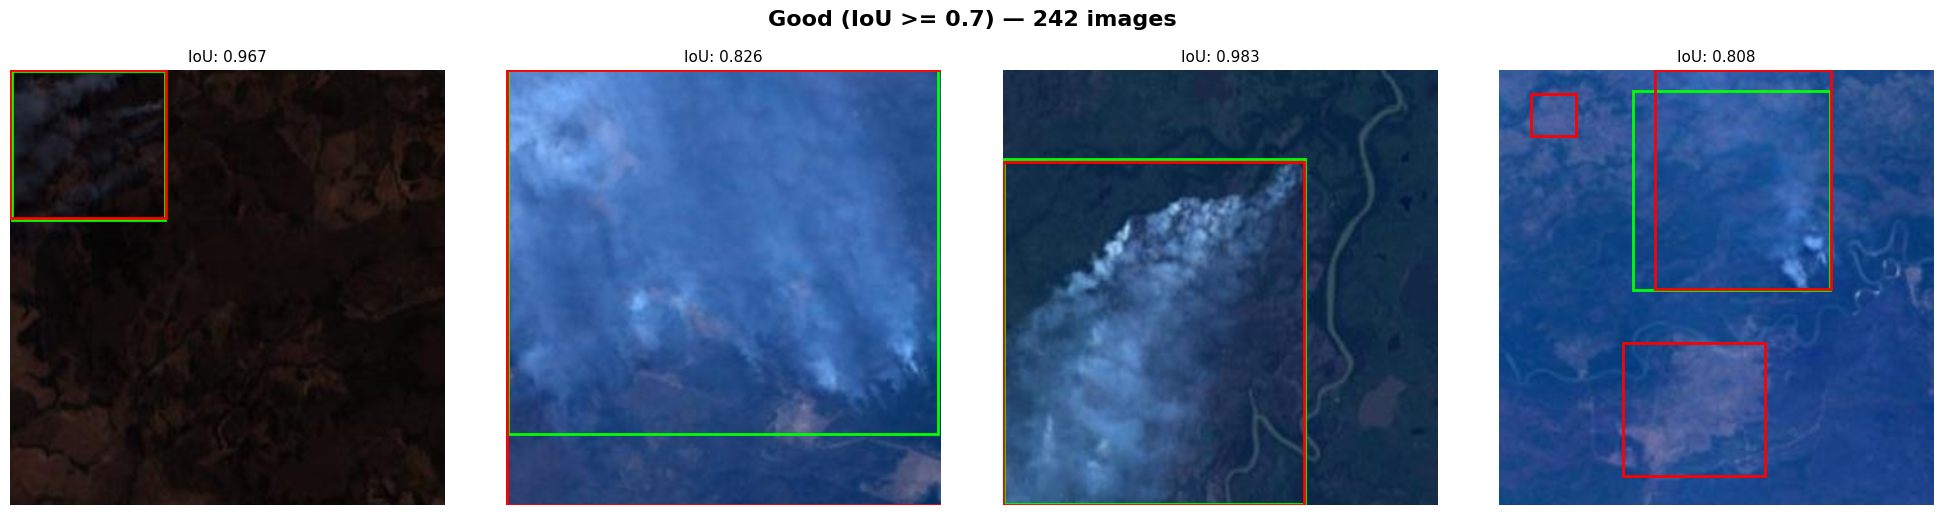

Saved: histogram_results/grid_good.png



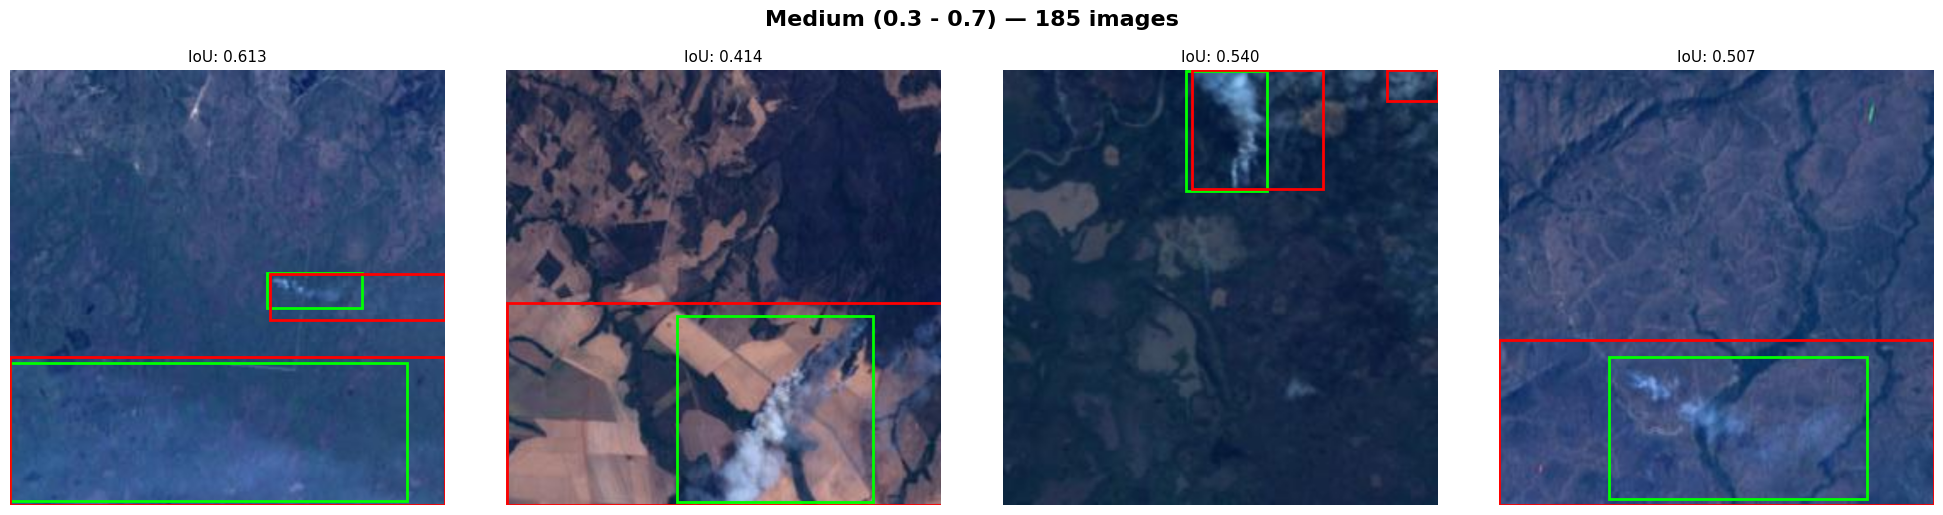

Saved: histogram_results/grid_medium.png



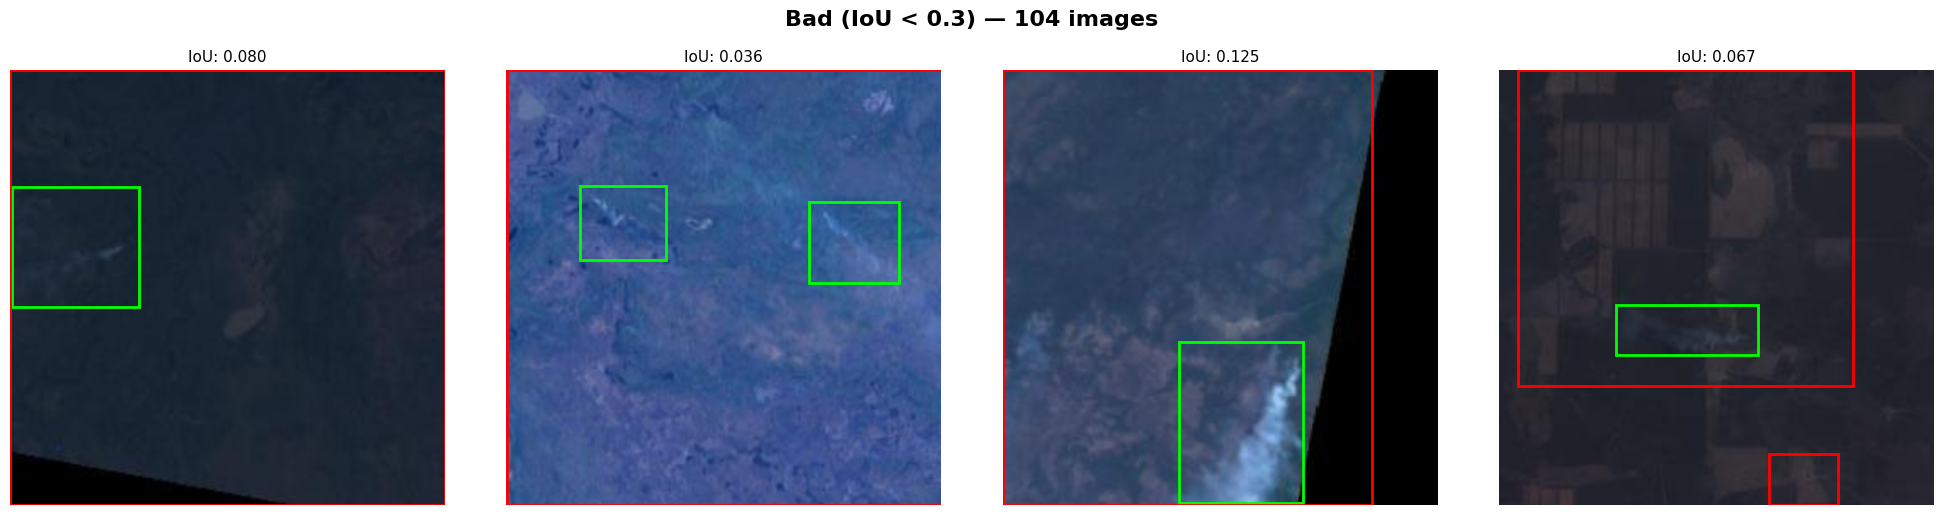

Saved: histogram_results/grid_bad.png



In [13]:
from torchvision import transforms as T

N_EXAMPLES = 4
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

to_tensor = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])

def load_for_display(path):
    img = Image.open(path).convert("RGB")
    tensor = to_tensor(img)
    return np.clip(tensor.permute(1, 2, 0).numpy(), 0, 1)

bands = [
    ("Good (IoU >= 0.7)",  [(fn, iou, p, g, pr) for fn, iou, p, g, pr in image_ious if iou >= 0.7]),
    ("Medium (0.3 - 0.7)", [(fn, iou, p, g, pr) for fn, iou, p, g, pr in image_ious if 0.3 <= iou < 0.7]),
    ("Bad (IoU < 0.3)",    [(fn, iou, p, g, pr) for fn, iou, p, g, pr in image_ious if iou < 0.3]),
]

try:
    font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", size=18)
except (OSError, IOError):
    font = ImageFont.load_default()

for band_name, band_items in bands:
    if len(band_items) > N_EXAMPLES:
        indices = np.linspace(0, len(band_items) - 1, N_EXAMPLES, dtype=int)
        samples = [band_items[i] for i in indices]
    else:
        samples = band_items

    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    fig.suptitle(f"{band_name} — {len(band_items)} images", fontsize=16, weight="bold", y=1.02)

    for ax, (fn, iou, path, gts, preds) in zip(axes, samples):
        if not os.path.exists(path):
            ax.set_visible(False)
            continue

        img_display = load_for_display(path)
        ax.imshow(img_display)

        from matplotlib.patches import Rectangle

        for gt in gts:
            x1, y1, x2, y2 = normalize_bbox(gt[:4])
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none'))

        for pred in preds:
            px1, py1, px2, py2 = float(pred[0]), float(pred[1]), float(pred[2]), float(pred[3])
            ax.add_patch(Rectangle((px1, py1), px2 - px1, py2 - py1, linewidth=2, edgecolor='red', facecolor='none'))

        ax.set_title(f"IoU: {iou:.3f}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    grid_path = os.path.join(OUTPUT_DIR, f"grid_{band_name.split('(')[0].strip().lower()}.png")
    plt.savefig(grid_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grid_path}\n")

## CorLoc and mAP: Full vs Without Bad Images

In [18]:
from collections import defaultdict
from core.metrics import calculate_corloc, calculate_map

_, filename_to_id, image_sizes = VisUtils.get_image_ids("Test")

bbox_to_id_scaled = defaultdict(list)
for filename, bboxes in gt_bboxes_by_filename.items():
    img_id = filename_to_id.get(filename)
    if img_id:
        for bb in bboxes:
            bbox_to_id_scaled[img_id].append(tuple(bb))

_filter_source = image_ious_ref if "image_ious_ref" in dir() else image_ious
bad_filenames = set(fn for fn, iou, _, _, _ in _filter_source if iou < 0.3)

all_predictions = []
filtered_predictions = []
filtered_bbox_to_id = defaultdict(list)

for fn, iou_val, img_path, gts, preds in image_ious:
    img_id = filename_to_id.get(fn)
    if not img_id:
        continue

    pred_entry = (img_id, preds, img_size, image_sizes, 0)
    all_predictions.append(pred_entry)

    if fn not in bad_filenames:
        filtered_predictions.append(pred_entry)
        if img_id in bbox_to_id_scaled:
            filtered_bbox_to_id[img_id] = bbox_to_id_scaled[img_id]

y_true_all, y_pred_all = [], []
y_true_filt, y_pred_filt = [], []
with torch.no_grad():
    for batch_data in test_loader:
        if len(batch_data) < 3:
            continue
        images, labels, paths = batch_data[0], batch_data[1], batch_data[2]
        images = images.to(device)
        outputs = model(images)
        logits = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        preds_batch = logits.argmax(dim=1).cpu().numpy()
        true_batch = labels.numpy() if isinstance(labels, torch.Tensor) else np.array(labels)

        for i in range(len(true_batch)):
            y_true_all.append(true_batch[i])
            y_pred_all.append(preds_batch[i])
            filename = os.path.basename(paths[i])
            if filename not in bad_filenames:
                y_true_filt.append(true_batch[i])
                y_pred_filt.append(preds_batch[i])

def cls_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true != 0) & (y_pred == 0)))
    fn = int(np.sum((y_true == 0) & (y_pred != 0)))
    precision = tp / (tp + fp)   if (tp + fp) > 0           else 0.0
    recall    = tp / (tp + fn)   if (tp + fn) > 0           else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

precision_all,  recall_all,  f1_all  = cls_metrics(y_true_all,  y_pred_all)
precision_filt, recall_filt, f1_filt = cls_metrics(y_true_filt, y_pred_filt)

print(f"{'=' * 70}")
print(f"METRICS COMPARISON")
print(f"{'=' * 70}")
print(f"Total images:         {len(all_predictions)}")
print(f"Excluded images:      {len(bad_filenames)} (IoU < 0.3{'  [fixed ref]' if 'image_ious_ref' in dir() else ''})")
print(f"Remaining images:     {len(filtered_predictions)}")
print(f"{'=' * 70}")

print(f"\n>>> ALL IMAGES ({len(all_predictions)}):")
corloc_all = calculate_corloc(all_predictions, bbox_to_id_scaled)
map_all = calculate_map(all_predictions, bbox_to_id_scaled)

print(f"\n>>> WITHOUT BAD IMAGES ({len(filtered_predictions)}):")
corloc_filtered = calculate_corloc(filtered_predictions, filtered_bbox_to_id)
map_filtered = calculate_map(filtered_predictions, filtered_bbox_to_id)

ious_all = np.array([x[1] for x in image_ious])
ious_filt = np.array([x[1] for x in image_ious if x[0] not in bad_filenames])

def diff_str(a, b):
    return f"{'+' if b > a else ''}{b - a:.4f}"

print(f"\n{'=' * 70}")
print(f"{'Metric':<20} {'Full':<20} {'Filtered':<20} {'Difference':<15}")
print(f"{'-' * 70}")
print(f"{'CorLoc (%)':<20} {corloc_all:<20.2f} {corloc_filtered:<20.2f} {'+' if corloc_filtered > corloc_all else ''}{corloc_filtered - corloc_all:.2f}")
print(f"{'mAP':<20} {map_all:<20.4f} {map_filtered:<20.4f} {diff_str(map_all, map_filtered):<15}")
print(f"{'Mean IoU':<20} {ious_all.mean():<20.4f} {ious_filt.mean():<20.4f} {diff_str(ious_all.mean(), ious_filt.mean()):<15}")
print(f"{'Median IoU':<20} {np.median(ious_all):<20.4f} {np.median(ious_filt):<20.4f} {diff_str(np.median(ious_all), np.median(ious_filt)):<15}")
print(f"{'-' * 70}")
print(f"{'Precision':<20} {precision_all:<20.4f} {precision_filt:<20.4f} {diff_str(precision_all, precision_filt):<15}")
print(f"{'Recall':<20} {recall_all:<20.4f} {recall_filt:<20.4f} {diff_str(recall_all, recall_filt):<15}")
print(f"{'F1-Score':<20} {f1_all:<20.4f} {f1_filt:<20.4f} {diff_str(f1_all, f1_filt):<15}")
print(f"{'=' * 70}")

[2026-02-19 16:32:47] INFO:     Loaded annotations in COCO format: data_fire/Test/annotations.json
[2026-02-19 16:32:47] INFO:     Images: 531, Annotations: 609
[2026-02-19 16:34:00] INFO:     ============================================================
[2026-02-19 16:34:00] INFO:     Calculating CorLoc (Correct Localization) - WSOL/WSOD
[2026-02-19 16:34:00] INFO:     IoU Threshold: 0.5
[2026-02-19 16:34:00] INFO:       Class 1: CorLoc = 52.35% (278/531 images)
[2026-02-19 16:34:00] INFO:       Class 2: CorLoc = 0.00% (0/0 images)
[2026-02-19 16:34:00] INFO:     ============================================================
[2026-02-19 16:34:00] INFO:     Computing mAP (mean Average Precision) - WSOD
[2026-02-19 16:34:00] INFO:     Total predictions: 531
[2026-02-19 16:34:00] INFO:     Total GTs: 609
[2026-02-19 16:34:00] INFO:     Classes with GTs: [1]
[2026-02-19 16:34:00] INFO:     IoU thresholds: [0.5]
[2026-02-19 16:34:00] INFO:     Computing AP for IoU=0.5...
[2026-02-19 16:34:00]

METRICS COMPARISON
Total images:         531
Excluded images:      104 (IoU < 0.3  [fixed ref])
Remaining images:     427

>>> ALL IMAGES (531):

>>> WITHOUT BAD IMAGES (427):

Metric               Full                 Filtered             Difference     
----------------------------------------------------------------------
CorLoc (%)           52.35                60.19                +7.83
mAP                  0.2875               0.3720               +0.0845        
Mean IoU             0.4491               0.5042               +0.0551        
Median IoU           0.4566               0.5445               +0.0879        
----------------------------------------------------------------------
Precision            0.8947               0.8722               -0.0226        
Recall               0.9925               0.9906               -0.0018        
F1-Score             0.9411               0.9276               -0.0134        
